# 🌲 Random Forest Classifier - Crop Recommendation

## Overview
Random Forest is an **ensemble learning method** that constructs multiple decision trees during training and outputs the class that is the mode (most common) of the classes predicted by individual trees.

### Key Concepts:
- **Bagging (Bootstrap Aggregating)**: Each tree is trained on a random subset of the data
- **Feature Randomness**: Each split considers only a random subset of features
- **Voting**: Final prediction is based on majority voting from all trees

### Advantages:
- Reduces overfitting compared to single Decision Tree
- Handles high-dimensional data well
- Provides feature importance rankings
- Robust to outliers and noise

In [ ]:
# =============================================================================
# 1. IMPORTS
# =============================================================================

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.preprocessing import LabelEncoder


In [ ]:
# =============================================================================
# 2. LOAD DATA
# =============================================================================

# Load the dataset
data_url = "https://raw.githubusercontent.com/dphi-official/Datasets/master/crop_recommendation/train_set_label.csv"
df = pd.read_csv(data_url)

df.head()

,N,P,K,temperature,humidity,ph,rainfall,crop
0,17.0,136.0,196.0,23.871923,90.499390,5.882156,103.054809,apple
1,49.0,69.0,82.0,18.315615,15.361435,7.263119,81.787105,chickpea
2,74.0,49.0,38.0,23.314104,71.450905,7.488014,164.497037,jute
3,104.0,35.0,28.0,27.510061,50.666872,6.983732,143.995555,coffee
4,23.0,72.0,84.0,19.020613,17.131591,6.920251,79.926981,chickpea


In [ ]:
# =============================================================================
# 3. PREPARE FEATURES AND TARGET
# =============================================================================

# Define feature columns
feature_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

# Separate features and target
X = df[feature_cols]
y = df['crop']

# Encode target labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"\nFeature columns: {feature_cols}")
print(f"\nNumber of classes: {len(label_encoder.classes_)}")


Feature columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

Number of classes: 22


In [ ]:
# =============================================================================
# 4. TRAIN-TEST SPLIT
# =============================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% for testing
    random_state=42,    # For reproducibility
    stratify=y          # Maintain class distribution
)

print(f"\nTraining set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")


Training set: 1320 samples (80.0%)
Test set: 330 samples (20.0%)


In [ ]:
# =============================================================================
# 5. BUILD RANDOM FOREST MODEL
# =============================================================================

model = RandomForestClassifier(
    n_estimators=100,        # Number of trees in the forest
    max_depth=10,            # Maximum depth of each tree
    min_samples_split=5,     # Minimum samples required to split a node
    min_samples_leaf=2,      # Minimum samples required in a leaf node
    max_features='sqrt',     # Number of features to consider for best split
    bootstrap=True,          # Whether to use bootstrap samples
    # oob_score=True,          # Use out-of-bag samples for accuracy estimation
    random_state=42,
    n_jobs=-1                # Use all available CPU cores
)

# Train the model
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [ ]:
# =============================================================================
# 6. PREDICTIONS
# =============================================================================

# Make predictions on test set
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)


In [ ]:
# =============================================================================
# 7. MODEL EVALUATION - METRICS
# =============================================================================

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Cross-validation
cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy', n_jobs=-1)
print(cv_scores)
print(cv_scores.mean())

print(f"Accuracy:  {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}  ({precision*100:.2f}%)")
print(f"Recall:    {recall:.4f}  ({recall*100:.2f}%)")
print(f"F1-Score:  {f1:.4f}  ({f1*100:.2f}%)")


[0.98484848 0.99090909 1.         1.         0.99393939]
0.9939393939393939
Accuracy:  0.9939  (99.39%)
Precision: 0.9947  (99.47%)
Recall:    0.9939  (99.39%)
F1-Score:  0.9939  (99.39%)


In [ ]:
# =============================================================================
# 8. CLASSIFICATION REPORT
# =============================================================================

print("=" * 60)
print("📋 DETAILED CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_pred))

📋 DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        15
      banana       1.00      1.00      1.00        15
   blackgram       1.00      1.00      1.00        15
    chickpea       1.00      1.00      1.00        15
     coconut       1.00      1.00      1.00        15
      coffee       1.00      1.00      1.00        15
      cotton       1.00      1.00      1.00        15
      grapes       1.00      1.00      1.00        15
        jute       0.88      1.00      0.94        15
 kidneybeans       1.00      1.00      1.00        15
      lentil       1.00      1.00      1.00        15
       maize       1.00      1.00      1.00        15
       mango       1.00      1.00      1.00        15
   mothbeans       1.00      1.00      1.00        15
    mungbean       1.00      1.00      1.00        15
   muskmelon       1.00      1.00      1.00        15
      orange       1.00      1.00      1.00     

Text(0.5, 1.0, '🎯 Confusion Matrix (Counts)')

/media/kushagra/DATA/notebook/crop/.venv/lib/python3.12/site-packages/IPython/core/events.py:96: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/media/kushagra/DATA/notebook/crop/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


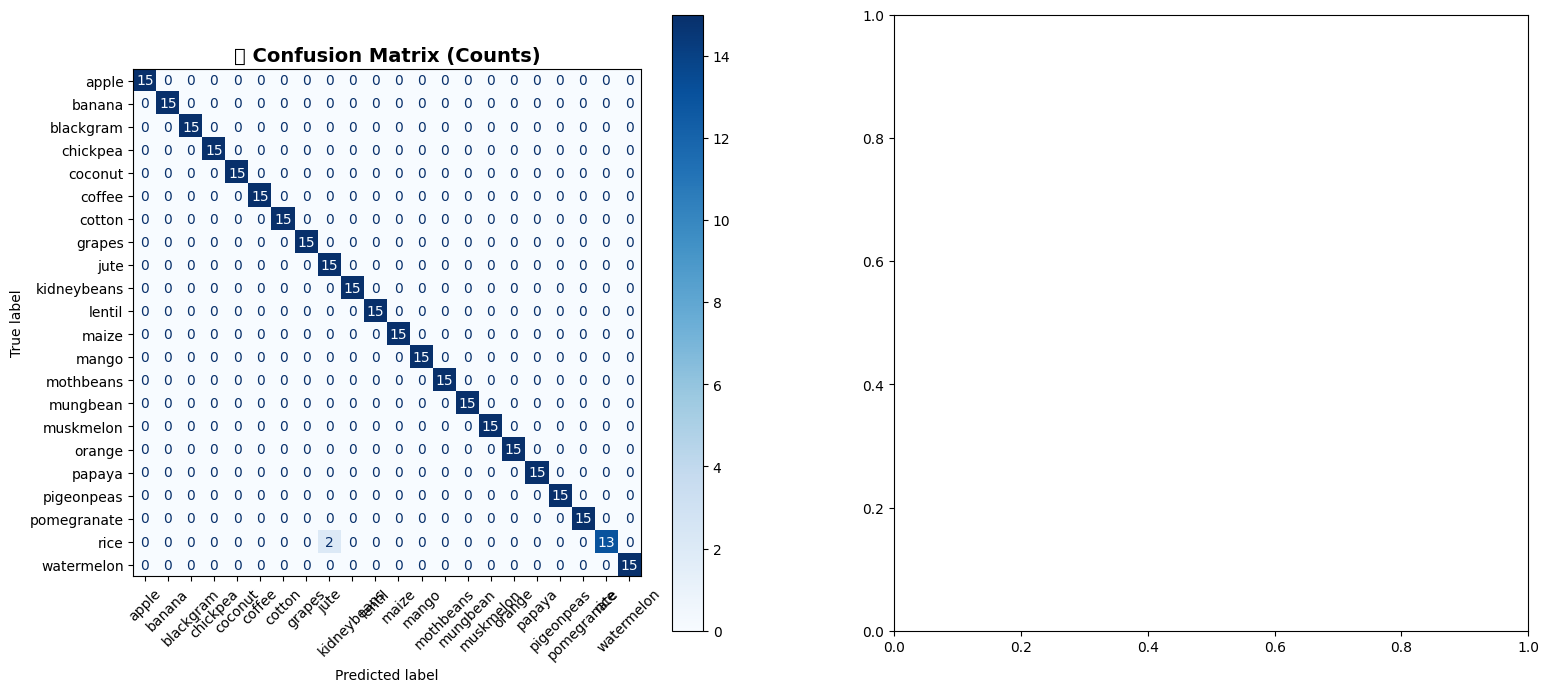

In [ ]:
# =============================================================================
# 9. CONFUSION MATRIX VISUALIZATION
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Plot 1: Raw counts
cm = confusion_matrix(y_test, y_pred)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp1.plot(ax=axes[0], cmap='Blues', xticks_rotation=45)
axes[0].set_title('🎯 Confusion Matrix (Counts)', fontsize=14, fontweight='bold')

# # Plot 2: Normalized (percentages)
# cm_normalized = confusion_matrix(y_test, y_pred, normalize='true')
# disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=model.classes_)
# disp2.plot(ax=axes[1], cmap='Greens', xticks_rotation=45, values_format='.2f')
# axes[1].set_title('🎯 Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')

# plt.tight_layout()
# plt.savefig('../../figures/rf_confusion_matrix.png', dpi=150, bbox_inches='tight', facecolor='white')
# plt.show()

# print("📁 Saved: figures/rf_confusion_matrix.png")

In [ ]:
# =============================================================================
# 10. FEATURE IMPORTANCE ANALYSIS
# =============================================================================

# Create feature importance DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=True)
# Add percentage
# importance_df['Importance_%'] = (importance_df['Importance'] * 100).round(2)

print(importance_df)



       Feature  Importance
5           ph    0.051670
3  temperature    0.079595
0            N    0.105182
1            P    0.147387
2            K    0.179619
4     humidity    0.212657
6     rainfall    0.223889


([<matplotlib.patches.Wedge at 0x7ae2ed712720>,
 [Text(1.0855393248783929, 0.17777619115776794, 'ph'),
  Text(0.9232862889769411, 0.5979485166694442, 'temperature'),
  Text(0.4441075595626696, 1.006363987600555, 'N'),
  Text(-0.4058395169810441, 1.0223963450915663, 'P'),
  Text(-1.0849511614298522, 0.18133112615327512, 'K'),
  Text(-0.5312492785373656, -0.9632103633441289, 'humidity'),
  Text(0.8389339147030265, -0.7114702290054414, 'rainfall')],
 [Text(0.5921123590245778, 0.0969688315406007, '5.2%'),
  Text(0.5036107030783314, 0.3261537363651513, '8.0%'),
  Text(0.2422404870341834, 0.5489258114184845, '10.5%'),
  Text(-0.22136700926238767, 0.5576707336863088, '14.7%'),
  Text(-0.5917915425981012, 0.09890788699269552, '18.0%'),
  Text(-0.28977233374765393, -0.5253874709149793, '21.3%'),
  Text(0.4576003171107417, -0.3880746703666044, '22.4%')])

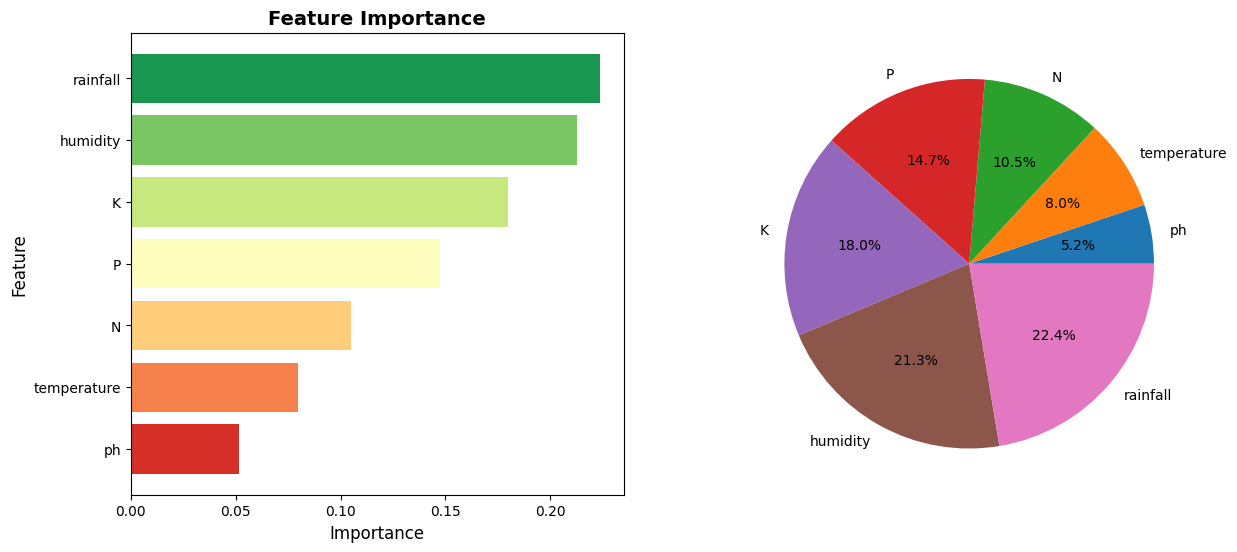

In [ ]:
# =============================================================================
# 11. FEATURE IMPORTANCE VISUALIZATION
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Horizontal Bar Chart
colors = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(feature_cols)))
axes[0].barh(importance_df['Feature'], importance_df['Importance'], color=colors)
axes[0].set_xlabel('Importance', fontsize=12)
axes[0].set_ylabel('Feature', fontsize=12)
axes[0].set_title('Feature Importance', fontsize=14, fontweight='bold')


# Plot 2: Pie Chart
axes[1].pie(
    importance_df['Importance'], 
    labels=importance_df['Feature'],
    autopct='%1.1f%%',
)
# axes[1].set_title('🌲 Feature Importance (Pie Chart)', fontsize=14, fontweight='bold')

# plt.tight_layout()
# plt.savefig('../../figures/rf_feature_importance.png', dpi=150, bbox_inches='tight', facecolor='white')
# plt.show()

# print("📁 Saved: figures/rf_feature_importance.png")

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [10, 25, 50, 75, 100, 150, 200],
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,  # 5-fold cross-validation
    verbose=1,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print(f"Best params: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 756 candidates, totalling 3780 fits


/media/kushagra/DATA/notebook/crop/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 10}
Best CV score: 0.9947


In [ ]:
# =============================================================================
# 13. COMPARISON WITH DECISION TREE
# =============================================================================

# Train Decision Tree with same parameters
dt_model = DecisionTreeClassifier(
    max_depth=15,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)
dt_model.fit(X_train, y_train)

# Evaluate both models
dt_train_acc = dt_model.score(X_train, y_train)
dt_test_acc = dt_model.score(X_test, y_test)
dt_cv = cross_val_score(dt_model, X, y, cv=5).mean()

rf_train_acc = model.score(X_train, y_train)
rf_test_acc = accuracy
rf_cv = cv_scores.mean()

print('dt_train_acc', dt_train_acc)
print('dt_test_acc', dt_test_acc)
print('dt_cv', dt_cv)
print('rf_train_acc', rf_train_acc)
print('rf_test_acc', rf_test_acc)
print('rf_cv', rf_cv)


dt_train_acc 1.0
dt_test_acc 0.9848484848484849
dt_cv 0.9818181818181818
rf_train_acc 0.9984848484848485
rf_test_acc 0.9939393939393939
rf_cv 0.9939393939393939


In [ ]:
# =============================================================================
# 14. SAMPLE PREDICTIONS
# =============================================================================



# Sample inputs
samples = [
    {'N': 90, 'P': 42, 'K': 43, 'temperature': 20.87, 'humidity': 82.0, 'ph': 6.5, 'rainfall': 202.9},
    {'N': 20, 'P': 30, 'K': 10, 'temperature': 30.0, 'humidity': 90.0, 'ph': 6.0, 'rainfall': 150.0},
    {'N': 40, 'P': 60, 'K': 55, 'temperature': 25.0, 'humidity': 60.0, 'ph': 7.0, 'rainfall': 100.0},
]

for i, sample in enumerate(samples, 1):
    sample_df = pd.DataFrame([sample])
    prediction = model.predict(sample_df)[0]
    proba = model.predict_proba(sample_df)[0]
    confidence = max(proba) * 100
    

    print(f"   Input: N={sample['N']}, P={sample['P']}, K={sample['K']}, ")
    print(f"          temp={sample['temperature']}°C, humidity={sample['humidity']}%, ")
    print(f"          ph={sample['ph']}, rainfall={sample['rainfall']}mm")
    print(f"   Predicted Crop: {prediction}")
    print(f"   Confidence: {confidence:.2f}%")
    


   Input: N=90, P=42, K=43, 
          temp=20.87°C, humidity=82.0%, 
          ph=6.5, rainfall=202.9mm
   Predicted Crop: rice
   Confidence: 88.49%
   Input: N=20, P=30, K=10, 
          temp=30.0°C, humidity=90.0%, 
          ph=6.0, rainfall=150.0mm
   Predicted Crop: orange
   Confidence: 52.90%
   Input: N=40, P=60, K=55, 
          temp=25.0°C, humidity=60.0%, 
          ph=7.0, rainfall=100.0mm
   Predicted Crop: pigeonpeas
   Confidence: 24.57%


In [ ]:
import joblib
from pathlib import Path

model_obj = globals().get("model")
if model_obj is None:
    for name in ["best_model", "rf_model", "best_rf_model", "grid_search"]:
        if name in globals():
            candidate = globals()[name]
            model_obj = getattr(candidate, "best_estimator_", candidate)
            break

if model_obj is None:
    raise ValueError("No trained model variable found in notebook globals.")

output_path = Path("../../models/random_forest.pkl")
output_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(model_obj, output_path)
print(f"Saved model to: {output_path.resolve()}")

## Quick inference test

Use the next cell to test the trained model on your own input values.

In [ ]:
# INFERENCE_TEST_SAMPLE
import pandas as pd
import numpy as np

# Update these values to test custom input
sample_input = {
    "N": 90,
    "P": 42,
    "K": 43,
    "temperature": 20.9,
    "humidity": 82.0,
    "ph": 6.5,
    "rainfall": 202.9,
}

feature_order = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
input_df = pd.DataFrame([sample_input])[feature_order]

model_candidates = [
    "knn_final", "gb_final", "dt_model", "model", "nb_baseline", "svm_baseline", "knn_cls", "gs", "grid_search"
]
model_obj = next((globals().get(name) for name in model_candidates if globals().get(name) is not None), None)

if model_obj is None:
    raise NameError(f"No trained model found. Checked: {model_candidates}")

if hasattr(model_obj, "best_estimator_"):
    model_obj = model_obj.best_estimator_

scaler_obj = globals().get("scaler")
if scaler_obj is not None:
    scaled_values = scaler_obj.transform(input_df)
    if "X_train_scaler_df" in globals():
        input_for_model = pd.DataFrame(scaled_values, columns=feature_order)
    else:
        input_for_model = scaled_values
else:
    input_for_model = input_df

raw_prediction = model_obj.predict(input_for_model)[0]
encoder_obj = globals().get("le") or globals().get("label_encoder")

if encoder_obj is not None:
    try:
        predicted_crop = encoder_obj.inverse_transform([int(raw_prediction)])[0]
    except Exception:
        predicted_crop = str(raw_prediction)
else:
    predicted_crop = str(raw_prediction)

print("Input sample:")
print(input_df)
print(f"\nPredicted crop: {predicted_crop}")

if hasattr(model_obj, "predict_proba"):
    probabilities = model_obj.predict_proba(input_for_model)[0]
    top_indices = np.argsort(probabilities)[-3:][::-1]

    if encoder_obj is not None and hasattr(encoder_obj, "classes_"):
        top_labels = [encoder_obj.classes_[idx] for idx in top_indices]
    else:
        top_labels = [str(idx) for idx in top_indices]

    print("\nTop 3 class probabilities:")
    for label, idx in zip(top_labels, top_indices):
        print(f"- {label}: {probabilities[idx]:.4f}")

